In [ ]:
results = {}

In [ ]:
!pip install tensorflow matplotlib pandas

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
import gc

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import tensorflow as tf

In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

X_train = X_train[:40000]
y_train = y_train[:40000]

X_test = X_test[:10000]
y_test = y_test[:10000]

NameError: name 'tf' is not defined

In [ ]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

X_train = X_train[:40000]
y_train = y_train[:40000]

X_test = X_test[:10000]
y_test = y_test[:10000]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


In [ ]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (50000, 32, 32, 3)
Testing Shape: (10000, 32, 32, 3)


In [ ]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (40000, 32, 32, 3)
Testing Shape: (10000, 32, 32, 3)


In [ ]:
IMG_SIZE = 96
BATCH_SIZE = 1000

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(1000)
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)


In [ ]:
IMG_SIZE = 96
BATCH_SIZE = 1000

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(1000)
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [ ]:
print("\nTraining CNN...")

cnn = models.Sequential([
    layers.Input(shape=(96,96,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds,
    verbose=1
)

loss, acc = cnn.evaluate(test_ds, verbose=0)
results["CNN"] = acc * 100

tf.keras.backend.clear_session()
gc.collect()


Training CNN...
Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 36s 371ms/step - accuracy: 0.3054 - loss: 1.9097 - val_accuracy: 0.4475 - val_loss: 1.5645
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 270ms/step - accuracy: 0.4504 - loss: 1.5279 - val_accuracy: 0.5203 - val_loss: 1.3474
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 272ms/step - accuracy: 0.5134 - loss: 1.3571 - val_accuracy: 0.5655 - val_loss: 1.2394
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 272ms/step - accuracy: 0.5534 - loss: 1.2597 - val_accuracy: 0.5902 - val_loss: 1.1497
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 273ms/step - accuracy: 0.5878 - loss: 1.1666 - val_accuracy: 0.5899 - val_loss: 1.1354


0

In [ ]:
print("\nTraining CNN...")

cnn = models.Sequential([
    layers.Input(shape=(96,96,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds,
    verbose=1
)

loss, acc = cnn.evaluate(test_ds, verbose=0)
results["CNN"] = acc * 100

tf.keras.backend.clear_session()
gc.collect()


Training CNN...


NameError: name 'models' is not defined

In [ ]:
def train_pretrained(base_model_fn, model_name):

    print(f"\nTraining {model_name}...")

    base_model = base_model_fn(
        weights='imagenet',
        include_top=False,
        input_shape=(96,96,3)
    )

    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        train_ds,
        epochs=3,
        validation_data=test_ds,
        verbose=1
    )

    loss, acc = model.evaluate(test_ds, verbose=0)

    results[model_name] = acc * 100

    tf.keras.backend.clear_session()
gc.collect()

0

In [ ]:
def train_pretrained(base_model_fn, model_name):

    print(f"\nTraining {model_name}...")

    base_model = base_model_fn(
        weights='imagenet',
        include_top=False,
        input_shape=(96,96,3)
    )

    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        train_ds,
        epochs=3,
        validation_data=test_ds,
        verbose=1
    )

    loss, acc = model.evaluate(test_ds, verbose=0)

    results[model_name] = acc * 100

    tf.keras.backend.clear_session()
gc.collect()

NameError: name 'gc' is not defined

In [ ]:
train_pretrained(
    MobileNetV2,
    "MobileNetV2"
)


Training MobileNetV2...
Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 251ms/step - accuracy: 0.5865 - loss: 1.2362 - val_accuracy: 0.7477 - val_loss: 0.7240
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - accuracy: 0.7397 - loss: 0.7596 - val_accuracy: 0.7796 - val_loss: 0.6379
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 169ms/step - accuracy: 0.7659 - loss: 0.6782 - val_accuracy: 0.7889 - val_loss: 0.6045


In [ ]:
train_pretrained(
    MobileNetV2,
    "MobileNetV2"
)

NameError: name 'MobileNetV2' is not defined

In [ ]:
train_pretrained(
    ResNet50,
    "ResNet50"
)


Training ResNet50...
Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 63s 660ms/step - accuracy: 0.1239 - loss: 2.3196 - val_accuracy: 0.1879 - val_loss: 2.2656
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 558ms/step - accuracy: 0.1853 - loss: 2.2428 - val_accuracy: 0.2384 - val_loss: 2.2077
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 556ms/step - accuracy: 0.2126 - loss: 2.1787 - val_accuracy: 0.2466 - val_loss: 2.1353


In [ ]:
train_pretrained(
    ResNet50,
    "ResNet50"
)

NameError: name 'ResNet50' is not defined

In [ ]:
train_pretrained(
    EfficientNetB0,
    "EfficientNetB0"
)


Training EfficientNetB0...
Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 49s 361ms/step - accuracy: 0.0999 - loss: 2.3081 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 207ms/step - accuracy: 0.0973 - loss: 2.3026 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 208ms/step - accuracy: 0.0977 - loss: 2.3026 - val_accuracy: 0.1000 - val_loss: 2.3026


In [ ]:
train_pretrained(
    EfficientNetB0,
    "EfficientNetB0"
)

NameError: name 'EfficientNetB0' is not defined

In [ ]:
from tensorflow.keras.applications import VGG16

train_pretrained(
    VGG16,
    "VGG16"
)


Training VGG16...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.3244 - loss: 1.9530 - val_accuracy: 0.5044 - val_loss: 1.5633
Epoch 2/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.5025 - loss: 1.4706 - val_accuracy: 0.5696 - val_loss: 1.3060
Epoch 3/3
50/50 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.5560 - loss: 1.2999 - val_accuracy: 0.5997 - val_loss: 1.1965


In [ ]:
from tensorflow.keras.applications import VGG16

train_pretrained(
    VGG16,
    "VGG16"
)


Training VGG16...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


NameError: name 'models' is not defined

In [ ]:
print("\n============================")
print("MODEL ACCURACY COMPARISON")
print("============================")

for model, accuracy in results.items():
    print(f"{model:15s} : {accuracy:.2f}%")


MODEL ACCURACY COMPARISON
CNN             : 58.99%
MobileNetV2     : 78.89%
ResNet50        : 24.66%
EfficientNetB0  : 10.00%


In [ ]:
print("\n============================")
print("MODEL ACCURACY COMPARISON")
print("============================")

for model, accuracy in results.items():
    print(f"{model:15s} : {accuracy:.2f}%")


MODEL ACCURACY COMPARISON


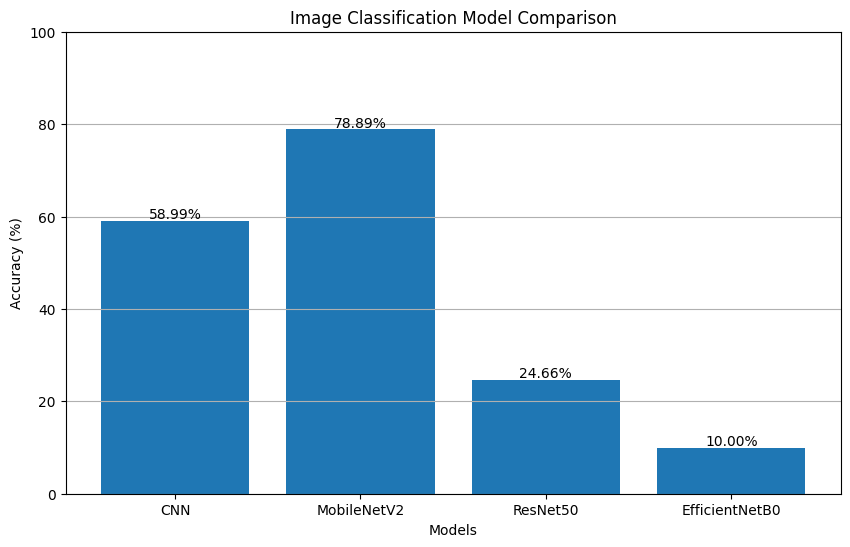

In [ ]:
model_names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(10,6))

bars = plt.bar(model_names, accuracies)

plt.title("Image Classification Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.5,
        f"{y:.2f}%",
        ha='center'
    )

plt.ylim(0,100)
plt.grid(axis='y')

plt.show()

In [ ]:
model_names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(10,6))

bars = plt.bar(model_names, accuracies)

plt.title("Image Classification Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + 0.5,
        f"{y:.2f}%",
        ha='center'
    )

plt.ylim(0,100)
plt.grid(axis='y')

plt.show()

NameError: name 'plt' is not defined

In [ ]:
best_model = max(results, key=results.get)

print("\nBest Model:", best_model)
print("Best Accuracy:", round(results[best_model],2), "%")


Best Model: MobileNetV2
Best Accuracy: 78.89 %


In [ ]:
best_model = max(results, key=results.get)

print("\nBest Model:", best_model)
print("Best Accuracy:", round(results[best_model],2), "%")

ValueError: max() iterable argument is empty

In [ ]:
results = {}